<a href="https://colab.research.google.com/github/socooked/INST326/blob/main/BMorrisModule4AssignmentINST414.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**The Question: "Are federal data-related job titles — like 'Data Scientist,' 'Data Analyst,' 'Statistician,' and 'Computer Scientist' — actually distinct roles, or do they cluster by structural characteristics (salary, grade, agency, occupational series) rather than title?"**

**Simplified: When you strip away the job title and just look at what an agency is actually offering — the pay, the grade level, the department, the occupational series — do "Data Scientists" and "Statisticians" end up in the same bucket? Or are they structurally different positions?**


Stakeholder: Same — a federal hiring manager trying to write better position descriptions. If a GS-13 "Data Scientist" at DoD has the same salary band, same occupational series, and same grade as a GS-13 "Statistician" at HHS, maybe those titles are interchangeable and the agency is just picking whichever sounds trendier.


Why this still works without job descriptions: You're arguing that even without reading the full text, the structural metadata tells you a lot. Two roles at the same GS level, same pay band, same occupational series, in the same type of agency are probably the same job in practice. If clusters separate cleanly by title, titles matter. If they don't, titles are just labels.

In [ ]:
cimport pandas as pd

# Load USAJobs export data
# Source: USAJobs.gov CSV export (https://www.usajobs.gov/)
df = pd.read_csv('/content/usajobs_export.csv')  # Replace with your file path

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (232421, 14)

Columns: ['Position Title', 'Occ. Series', 'Department', 'Agency', 'Grade', 'Min Salary', 'Max Salary', 'Open Date', 'Close Date', 'Appointment Type', 'Service', 'Locations', 'Status', 'Control Number']


,Position Title,Occ. Series,Department,Agency,Grade,Min Salary,Max Salary,Open Date,Close Date,Appointment Type,Service,Locations,Status,Control Number
0,Auditor (Performance),0511 - Auditing,Department of Housing and Urban Development,Department of Housing and Urban Development,GS-14,125776.0,197200.0,2026-04-06,2026-04-20,Permanent,Competitive,"Anchorage, Alaska; Birmingham, Alabama; Little...",NaN,863824400.0
1,Human Resources Specialist,0201 - Human Resources Management,Department of the Navy,Department of the Navy,GS-13,108019.0,140426.0,2026-04-06,2026-04-08,Permanent,Competitive,"Naval Shipyard, Portsmouth, Virginia",NaN,863593100.0
2,Supervisory Archivist,1420 - Archivist,Other Agencies and Independent Organizations,Other Agencies and Independent Organizations,GS-14,143913.0,187093.0,2026-04-06,2026-04-14,Permanent,Competitive,"College Park, Maryland",NaN,863875600.0
3,Health Physicist,1306 - Health Physics,National Aeronautics and Space Administration,National Aeronautics and Space Administration,GS-14,157236.0,197200.0,2026-04-06,2026-04-10,Permanent,Competitive,"Moffett Field, California",NaN,863910200.0
4,AIRCRAFT OVERHAUL SUPERVISOR,8801 - Miscellaneous Aircraft Overhaul,Department of the Air Force,Department of the Air Force,WS-13,96169.0,112197.0,2026-04-06,2026-04-10,Permanent,Competitive,"McConnell AFB, Kansas",NaN,863841400.0


In [ ]:
# Define keywords for data-related and statistician roles
data_keywords = ['data scientist', 'data analyst', 'data engineer',
                 'statistician', 'computer scientist', 'it specialist']

# Filter to rows where the title contains any of our keywords (case-insensitive)
mask = df['Position Title'].str.lower().str.contains('|'.join(data_keywords), na=False)
df_data = df[mask].copy()

print(f"Filtered from {len(df):,} → {len(df_data):,} data-relevant postings")
print(f"\nTitle breakdown:")
print(df_data['Position Title'].value_counts().head(20))

Filtered from 232,421 → 3,745 data-relevant postings

Title breakdown:
Position Title
IT SPECIALIST (INFOSEC)                187
IT Specialist (INFOSEC)                105
SUPERVISORY IT SPECIALIST (PLCYPLN)    104
IT SPECIALIST (NETWORK)                102
IT SPECIALIST (CUSTSPT)                 94
IT SPECIALIST (SYSADMIN)                92
IT SPECIALIST (APPSW)                   80
IT SPECIALIST (PLCYPLN)                 76
IT Specialist                           72
IT SPECIALIST (SYSANALYSIS)             63
Data Scientist                          61
Supervisory IT Specialist               56
IT Specialist (APPSW)                   52
COMPUTER SCIENTIST                      47
DATA SCIENTIST                          45
SUPERVISORY IT SPECIALIST (INFOSEC)     42
IT Specialist (CUSTSPT)                 38
IT Specialist (SYSANALYSIS)             33
IT SPECIALIST (SYSADMIN/CUSTSPT)        30
IT SPECIALIST (CUSTOMER SUPPORT)        29
Name: count, dtype: int64


In [ ]:
# IT Specialist is too broad - mostly infosec/sysadmin/network roles
# Keep only titles directly relevant to data/analytics work
data_keywords_narrow = ['data scientist', 'data analyst', 'data engineer',
                        'statistician', 'computer scientist']

mask = df['Position Title'].str.lower().str.contains('|'.join(data_keywords_narrow), na=False)
df_data = df[mask].copy()

print(f"Filtered to {len(df_data):,} data-relevant postings")
print(f"\nTitle breakdown:")
print(df_data['Position Title'].value_counts().head(20))

Filtered to 575 data-relevant postings

Title breakdown:
Position Title
Data Scientist                                            61
COMPUTER SCIENTIST                                        47
DATA SCIENTIST                                            45
Computer Scientist                                        29
Statistician                                              20
Mathematical Statistician                                 10
Supervisory Data Scientist                                 7
Survey Statistician                                        7
Supervisory Survey Statistician                            6
Research Statistician                                      6
Analysis Career Field (Data Scientist) (Washington DC)     6
WOC - Research Statistician                                5
Data Engineer                                              5
Financial Data Analyst                                     4
Data Scientist (Supply Chain)                              4
Data Analyst 

In [ ]:
# Assign standardized role labels based on title keywords
def assign_role(title):
    title_lower = title.lower()
    if 'data scientist' in title_lower:
        return 'Data Scientist'
    elif 'data analyst' in title_lower:
        return 'Data Analyst'
    elif 'data engineer' in title_lower:
        return 'Data Engineer'
    elif 'statistician' in title_lower:
        return 'Statistician'
    elif 'computer scientist' in title_lower:
        return 'Computer Scientist'
    else:
        return 'Other'

df_data['Role'] = df_data['Position Title'].apply(assign_role)

# Drop rows with missing salary info (we need these for clustering)
df_data = df_data.dropna(subset=['Min Salary', 'Max Salary'])

# Parse GS grade level as a number where possible
df_data['Grade_Level'] = df_data['Grade'].str.extract(r'(\d+)').astype(float)

# Convert dates
df_data['Open Date'] = pd.to_datetime(df_data['Open Date'])
df_data['Close Date'] = pd.to_datetime(df_data['Close Date'])

print(f"After cleaning: {len(df_data):,} postings\n")
print("Role distribution:")
print(df_data['Role'].value_counts())
print(f"\nGrade level range: {df_data['Grade_Level'].min():.0f} - {df_data['Grade_Level'].max():.0f}")
print(f"Salary range: ${df_data['Min Salary'].min():,.0f} - ${df_data['Max Salary'].max():,.0f}")

After cleaning: 575 postings

Role distribution:
Role
Data Scientist        209
Computer Scientist    188
Statistician          115
Data Analyst           52
Data Engineer          11
Name: count, dtype: int64

Grade level range: 0 - 22
Salary range: $0 - $256,833


In [ ]:
# Filter out unreasonable values
# GS grades typically range from 5-15 for professional roles
# Salary of $0 is clearly missing/bad data
df_data = df_data[
    (df_data['Grade_Level'] >= 5) &
    (df_data['Grade_Level'] <= 15) &
    (df_data['Min Salary'] > 0) &
    (df_data['Max Salary'] > 0)
]

print(f"After removing bad data: {len(df_data):,} postings\n")
print("Role distribution:")
print(df_data['Role'].value_counts())
print(f"\nGrade level range: {df_data['Grade_Level'].min():.0f} - {df_data['Grade_Level'].max():.0f}")
print(f"Salary range: ${df_data['Min Salary'].min():,.0f} - ${df_data['Max Salary'].max():,.0f}")
print(f"\nGrade breakdown:")
print(df_data['Grade_Level'].value_counts().sort_index())

After removing bad data: 447 postings

Role distribution:
Role
Data Scientist        186
Computer Scientist    130
Statistician           85
Data Analyst           40
Data Engineer           6
Name: count, dtype: int64

Grade level range: 5 - 15
Salary range: $20 - $256,833

Grade breakdown:
Grade_Level
5.0      21
6.0       2
7.0      52
9.0      22
11.0     41
12.0     44
13.0    130
14.0    102
15.0     33
Name: count, dtype: int64


In [ ]:
# Drop Data Engineer - too few postings (9) for meaningful clustering
df_data = df_data[df_data['Role'] != 'Data Engineer']

print(f"Final dataset: {len(df_data):,} postings across {df_data['Role'].nunique()} roles\n")
print("Role distribution:")
print(df_data['Role'].value_counts())
print(f"\n--- Preview ---")
df_data[['Position Title', 'Role', 'Occ. Series', 'Department', 'Grade_Level',
         'Min Salary', 'Max Salary', 'Appointment Type', 'Service']].head(10)

Final dataset: 441 postings across 4 roles

Role distribution:
Role
Data Scientist        186
Computer Scientist    130
Statistician           85
Data Analyst           40
Name: count, dtype: int64

--- Preview ---


,Position Title,Role,Occ. Series,Department,Grade_Level,Min Salary,Max Salary,Appointment Type,Service
469,INTERDISCIPLINARY COMPUTER ENGINEER/ ELECTRONI...,Computer Scientist,0854 - Computer Engineering; 0855 - Electronic...,Department of the Air Force,14.0,148275.0,197200.0,Permanent,Excepted
1046,Data Scientist,Data Scientist,1560 - Data Science Series,Department of the Army,13.0,109137.0,141880.0,Permanent,Competitive
1076,Computer Scientist (Data Scientist),Data Scientist,1550 - Computer Science,Department of Health and Human Services,14.0,125776.0,163514.0,Permanent,Competitive
1077,Data Scientist,Data Scientist,1560 - Data Science Series,Department of the Army,13.0,109137.0,141880.0,Permanent,Competitive
1750,Supervisory Statistician / Supervisory Data Sc...,Data Scientist,1530 - Statistics; 1560 - Data Science Series,Department of Labor,15.0,169279.0,197200.0,Permanent,Competitive
1751,Statistician (Health),Statistician,1530 - Statistics,Department of Veterans Affairs,12.0,105481.0,163062.0,Permanent,Competitive
2884,Mathematical Statistician (Recent Graduate),Statistician,1529 - Mathematical Statistics,Department of Commerce,7.0,59055.0,93912.0,Recent graduates,Excepted
3178,"Data Analyst, GS-0301- 13 FPL 13 (MP)",Data Analyst,0301 - Miscellaneous Administration And Program,Department of Education,13.0,108173.0,158322.0,Permanent,Competitive
3182,"Data Analyst, GS-0301- 13 FPL 13 (DE)",Data Analyst,0301 - Miscellaneous Administration And Program,Department of Education,13.0,108173.0,158322.0,Permanent,Competitive
3523,Student Trainee (Mathematical Statistician),Statistician,1599 - Mathematics And Statistics Student Trainee,Department of the Navy,7.0,50460.0,65599.0,Term,Competitive


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Feature 1: Mid-point salary (combines min and max into one meaningful number)
df_data['Mid Salary'] = (df_data['Min Salary'] + df_data['Max Salary']) / 2

# Feature 2: Salary spread (how wide is the pay band — indicates flexibility/negotiability)
df_data['Salary Spread'] = df_data['Max Salary'] - df_data['Min Salary']

# Feature 3: Grade level (already numeric)

# Feature 4: Occupational series - extract just the code number
df_data['Occ_Code'] = df_data['Occ. Series'].str.extract(r'(\d{4})').astype(float)

# Feature 5: Department (encode as numeric)
le_dept = LabelEncoder()
df_data['Dept_Encoded'] = le_dept.fit_transform(df_data['Department'])

# Feature 6: Service type (Competitive vs Excepted)
le_service = LabelEncoder()
df_data['Service_Encoded'] = le_service.fit_transform(df_data['Service'].fillna('Unknown'))

# Feature 7: Appointment type
le_appt = LabelEncoder()
df_data['Appt_Encoded'] = le_appt.fit_transform(df_data['Appointment Type'].fillna('Unknown'))

# Combine into feature matrix
features = ['Grade_Level', 'Mid Salary', 'Salary Spread', 'Occ_Code',
            'Dept_Encoded', 'Service_Encoded', 'Appt_Encoded']

X = df_data[features].dropna()
df_data = df_data.loc[X.index]  # Keep only rows that have all features

# Scale features so no single feature dominates the distance calculation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"\nFeatures used:")
for f in features:
    print(f"  - {f}")
print(f"\nRows retained: {len(df_data):,}")

Feature matrix shape: (441, 7)

Features used:
  - Grade_Level
  - Mid Salary
  - Salary Spread
  - Occ_Code
  - Dept_Encoded
  - Service_Encoded
  - Appt_Encoded

Rows retained: 441


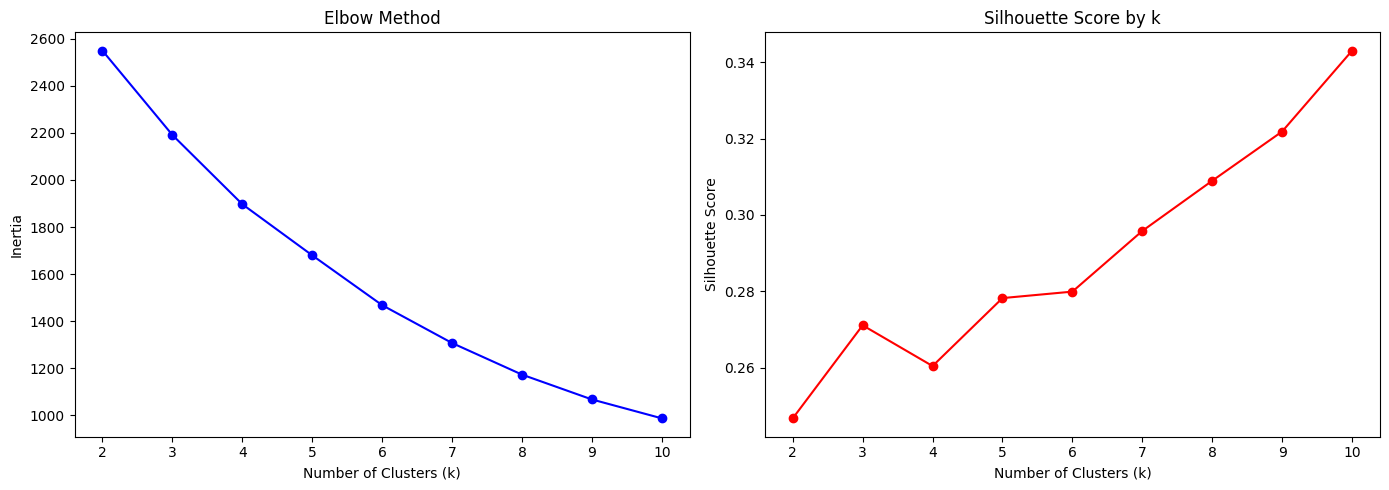

k=2: Inertia=2,550, Silhouette=0.2467
k=3: Inertia=2,191, Silhouette=0.2711
k=4: Inertia=1,897, Silhouette=0.2604
k=5: Inertia=1,679, Silhouette=0.2782
k=6: Inertia=1,468, Silhouette=0.2799
k=7: Inertia=1,306, Silhouette=0.2958
k=8: Inertia=1,172, Silhouette=0.3090
k=9: Inertia=1,066, Silhouette=0.3219
k=10: Inertia=986, Silhouette=0.3430


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Test k values from 2 to 10
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot both metrics side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(k_range))

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by k')
ax2.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# Print the scores
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"k={k}: Inertia={inertia:,.0f}, Silhouette={sil:.4f}")

In [ ]:
# Run KMeans with k=4
# Justification: k=4 sits at the elbow in our inertia plot, and since we have
# 4 job titles, this lets us directly test whether clusters align with titles.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Cross-tabulate: do clusters align with job titles?
ct = pd.crosstab(df_data['Role'], df_data['Cluster'], margins=True)
print("=== Role vs Cluster Crosstab ===\n")
print(ct)

# Show percentages within each cluster
print("\n=== Role distribution within each cluster (%) ===\n")
ct_pct = pd.crosstab(df_data['Role'], df_data['Cluster'], normalize='columns').round(3) * 100
print(ct_pct)

=== Role vs Cluster Crosstab ===

Cluster              0    1   2    3  All
Role                                     
Computer Scientist  24   46   5   55  130
Data Analyst        29    3   4    4   40
Data Scientist       6   46   9  125  186
Statistician        15   19   6   45   85
All                 74  114  24  229  441

=== Role distribution within each cluster (%) ===

Cluster                0     1     2     3
Role                                      
Computer Scientist  32.4  40.4  20.8  24.0
Data Analyst        39.2   2.6  16.7   1.7
Data Scientist       8.1  40.4  37.5  54.6
Statistician        20.3  16.7  25.0  19.7


In [ ]:
# Check what happened
print(f"df_data length: {len(df_data)}")
print(f"Cluster column non-null: {df_data['Cluster'].notna().sum()}")
print(f"X_scaled shape: {X_scaled.shape}")

df_data length: 441
Cluster column non-null: 441
X_scaled shape: (441, 7)


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ---- LOAD ----
df = pd.read_csv('usajobs_export.csv')  # Replace with your path

# ---- FILTER TO DATA ROLES ----
data_keywords = ['data scientist', 'data analyst', 'statistician', 'computer scientist']
mask = df['Position Title'].str.lower().str.contains('|'.join(data_keywords), na=False)
df_data = df[mask].copy()

# ---- ASSIGN ROLE LABELS ----
def assign_role(title):
    title_lower = title.lower()
    if 'data scientist' in title_lower:
        return 'Data Scientist'
    elif 'data analyst' in title_lower:
        return 'Data Analyst'
    elif 'statistician' in title_lower:
        return 'Statistician'
    elif 'computer scientist' in title_lower:
        return 'Computer Scientist'
    else:
        return 'Other'

df_data['Role'] = df_data['Position Title'].apply(assign_role)

# ---- CLEAN ----
df_data = df_data.dropna(subset=['Min Salary', 'Max Salary'])
df_data['Grade_Level'] = df_data['Grade'].str.extract(r'(\d+)').astype(float)
df_data = df_data[
    (df_data['Grade_Level'] >= 5) &
    (df_data['Grade_Level'] <= 15) &
    (df_data['Min Salary'] > 0) &
    (df_data['Max Salary'] > 0)
]

# ---- FEATURE ENGINEERING ----
df_data['Mid Salary'] = (df_data['Min Salary'] + df_data['Max Salary']) / 2
df_data['Salary Spread'] = df_data['Max Salary'] - df_data['Min Salary']
df_data['Occ_Code'] = df_data['Occ. Series'].str.extract(r'(\d{4})').astype(float)

le_dept = LabelEncoder()
df_data['Dept_Encoded'] = le_dept.fit_transform(df_data['Department'])
le_service = LabelEncoder()
df_data['Service_Encoded'] = le_service.fit_transform(df_data['Service'].fillna('Unknown'))
le_appt = LabelEncoder()
df_data['Appt_Encoded'] = le_appt.fit_transform(df_data['Appointment Type'].fillna('Unknown'))

features = ['Grade_Level', 'Mid Salary', 'Salary Spread', 'Occ_Code',
            'Dept_Encoded', 'Service_Encoded', 'Appt_Encoded']

valid_mask = df_data[features].notna().all(axis=1)
df_data = df_data[valid_mask].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_data[features])

print(f"Final dataset: {len(df_data):,} postings")
print(f"Feature matrix: {X_scaled.shape}")
print(f"\nRole distribution:")
print(df_data['Role'].value_counts())

Final dataset: 1,542 postings
Feature matrix: (1542, 7)

Role distribution:
Role
Data Scientist        677
Statistician          377
Computer Scientist    347
Data Analyst          141
Name: count, dtype: int64


In [ ]:
# Run KMeans with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Cross-tabulate: do clusters align with job titles?
print("=== Role vs Cluster Crosstab ===\n")
ct = pd.crosstab(df_data['Role'], df_data['Cluster'], margins=True)
print(ct)

print("\n=== Role distribution within each cluster (%) ===\n")
ct_pct = pd.crosstab(df_data['Role'], df_data['Cluster'], normalize='columns').round(3) * 100
print(ct_pct)

=== Role vs Cluster Crosstab ===

Cluster               0    1    2   3   All
Role                                       
Computer Scientist  127   92  106  22   347
Data Analyst         55   55   18  13   141
Data Scientist      375  155  110  37   677
Statistician        213  116   29  19   377
All                 770  418  263  91  1542

=== Role distribution within each cluster (%) ===

Cluster                0     1     2     3
Role                                      
Computer Scientist  16.5  22.0  40.3  24.2
Data Analyst         7.1  13.2   6.8  14.3
Data Scientist      48.7  37.1  41.8  40.7
Statistician        27.7  27.8  11.0  20.9


In [ ]:
# What makes each cluster different?
cluster_summary = df_data.groupby('Cluster').agg({
    'Grade_Level': 'mean',
    'Mid Salary': 'mean',
    'Salary Spread': 'mean',
    'Min Salary': 'mean',
    'Max Salary': 'mean',
    'Department': lambda x: x.value_counts().index[0],  # most common
    'Occ. Series': lambda x: x.value_counts().index[0],
    'Appointment Type': lambda x: x.value_counts().index[0],
    'Service': lambda x: x.value_counts().index[0],
    'Role': 'count'
}).rename(columns={'Role': 'Count'})

print("=== Cluster Profiles ===\n")
for i in range(4):
    row = cluster_summary.loc[i]
    print(f"--- Cluster {i} ({int(row['Count'])} postings) ---")
    print(f"  Avg Grade: GS-{row['Grade_Level']:.1f}")
    print(f"  Avg Salary: ${row['Min Salary']:,.0f} - ${row['Max Salary']:,.0f}")
    print(f"  Avg Mid Salary: ${row['Mid Salary']:,.0f}")
    print(f"  Avg Salary Spread: ${row['Salary Spread']:,.0f}")
    print(f"  Top Department: {row['Department']}")
    print(f"  Top Occ Series: {row['Occ. Series']}")
    print(f"  Appointment Type: {row['Appointment Type']}")
    print(f"  Service: {row['Service']}")
    print()

=== Cluster Profiles ===

--- Cluster 0 (770 postings) ---
  Avg Grade: GS-13.7
  Avg Salary: $125,857 - $167,932
  Avg Mid Salary: $146,894
  Avg Salary Spread: $42,075
  Top Department: Department of Health and Human Services
  Top Occ Series: 1560 - Data Science Series
  Appointment Type: Permanent
  Service: Competitive

--- Cluster 1 (418 postings) ---
  Avg Grade: GS-9.7
  Avg Salary: $81,627 - $131,812
  Avg Mid Salary: $106,720
  Avg Salary Spread: $50,185
  Top Department: Department of the Navy
  Top Occ Series: 1560 - Data Science Series
  Appointment Type: Permanent
  Service: Competitive

--- Cluster 2 (263 postings) ---
  Avg Grade: GS-11.3
  Avg Salary: $104,218 - $151,197
  Avg Mid Salary: $127,707
  Avg Salary Spread: $46,979
  Top Department: Department of Defense
  Top Occ Series: 1560 - Data Science Series
  Appointment Type: Permanent
  Service: Excepted

--- Cluster 3 (91 postings) ---
  Avg Grade: GS-11.7
  Avg Salary: $98,407 - $135,059
  Avg Mid Salary: $116,73

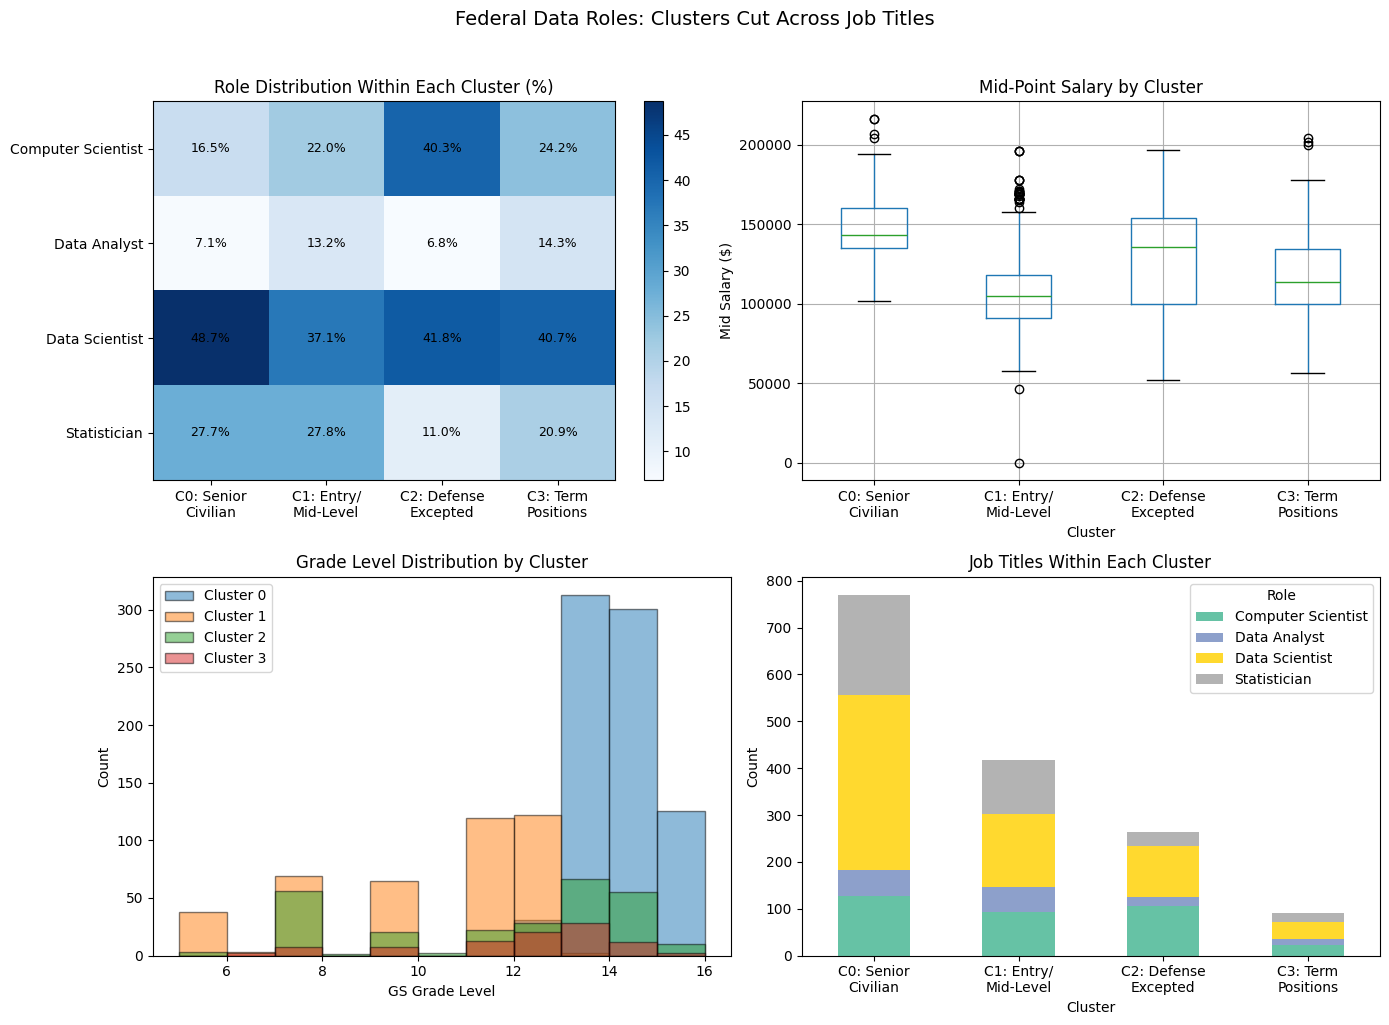

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Cluster vs Role heatmap
ct_pct = pd.crosstab(df_data['Role'], df_data['Cluster'], normalize='columns') * 100
im = axes[0, 0].imshow(ct_pct.values, cmap='Blues', aspect='auto')
axes[0, 0].set_xticks(range(4))
axes[0, 0].set_xticklabels(['C0: Senior\nCivilian', 'C1: Entry/\nMid-Level', 'C2: Defense\nExcepted', 'C3: Term\nPositions'])
axes[0, 0].set_yticks(range(4))
axes[0, 0].set_yticklabels(ct_pct.index)
axes[0, 0].set_title('Role Distribution Within Each Cluster (%)')
for i in range(4):
    for j in range(4):
        axes[0, 0].text(j, i, f'{ct_pct.values[i, j]:.1f}%', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes[0, 0])

# 2. Salary by cluster (boxplot)
cluster_labels = {0: 'C0: Senior\nCivilian', 1: 'C1: Entry/\nMid-Level',
                  2: 'C2: Defense\nExcepted', 3: 'C3: Term\nPositions'}
df_data['Cluster_Label'] = df_data['Cluster'].map(cluster_labels)
df_data.boxplot(column='Mid Salary', by='Cluster_Label', ax=axes[0, 1])
axes[0, 1].set_title('Mid-Point Salary by Cluster')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Mid Salary ($)')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# 3. Grade distribution by cluster
for c in range(4):
    subset = df_data[df_data['Cluster'] == c]
    axes[1, 0].hist(subset['Grade_Level'], bins=range(5, 17), alpha=0.5,
                     label=f'Cluster {c}', edgecolor='black')
axes[1, 0].set_title('Grade Level Distribution by Cluster')
axes[1, 0].set_xlabel('GS Grade Level')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# 4. Role distribution stacked bar
ct_raw = pd.crosstab(df_data['Cluster'], df_data['Role'])
ct_raw.index = [cluster_labels[i] for i in ct_raw.index]
ct_raw.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='Set2')
axes[1, 1].set_title('Job Titles Within Each Cluster')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Role', bbox_to_anchor=(1.0, 1.0))
axes[1, 1].tick_params(axis='x', rotation=0)

plt.suptitle('Federal Data Roles: Clusters Cut Across Job Titles', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Show 2 example postings from each cluster
print("=== Example Postings Per Cluster ===\n")
for c in range(4):
    subset = df_data[df_data['Cluster'] == c]
    print(f"--- Cluster {c}: {cluster_labels[c].replace(chr(10), ' ')} ---")
    samples = subset.sample(2, random_state=42)
    for _, row in samples.iterrows():
        print(f"  Title: {row['Position Title']}")
        print(f"  Agency: {row['Department']}")
        print(f"  Grade: GS-{int(row['Grade_Level'])} | Salary: ${row['Min Salary']:,.0f}-${row['Max Salary']:,.0f}")
        print(f"  Occ Series: {row['Occ. Series']}")
        print(f"  Appointment: {row['Appointment Type']} | Service: {row['Service']}")
        print()

=== Example Postings Per Cluster ===

--- Cluster 0: C0: Senior Civilian ---
  Title: Statistician (Health)
  Agency: Department of Health and Human Services
  Grade: GS-14 | Salary: $122,198-$158,860
  Occ Series: 1530 - Statistics
  Appointment: Permanent | Service: Competitive

  Title: Supervisory Data Scientist
  Agency: Department of the Army
  Grade: GS-14 | Salary: $136,414-$177,341
  Occ Series: 1560 - Data Science Series
  Appointment: Permanent | Service: Competitive

--- Cluster 1: C1: Entry/ Mid-Level ---
  Title: Survey Statistician
  Agency: Department of Commerce
  Grade: GS-7 | Salary: $55,924-$88,926
  Occ Series: 1530 - Statistics
  Appointment: Permanent | Service: Competitive

  Title: SUPERVISORY GENERAL ENGINEER/SUPERVISORY COMPUTER SCIENTIST
  Agency: Department of the Navy
  Grade: GS-6 | Salary: $188,561-$204,000
  Occ Series: 0801 - General Engineering; 1550 - Computer Science
  Appointment: Permanent | Service: Competitive

--- Cluster 2: C2: Defense Excepte

In [ ]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, df_data['Cluster'])
print(f"Silhouette Score (k=4): {sil_score:.4f}")
print()
print("Interpretation:")
print("- Silhouette scores range from -1 to 1")
print("- Scores near 0 indicate overlapping clusters")
print(f"- Our score of {sil_score:.4f} suggests moderate overlap between clusters")
print("- This is consistent with our finding: job titles blur across clusters")
print("  rather than forming distinct, well-separated groups")

Silhouette Score (k=4): 0.2429

Interpretation:
- Silhouette scores range from -1 to 1
- Scores near 0 indicate overlapping clusters
- Our score of 0.2429 suggests moderate overlap between clusters
- This is consistent with our finding: job titles blur across clusters
  rather than forming distinct, well-separated groups


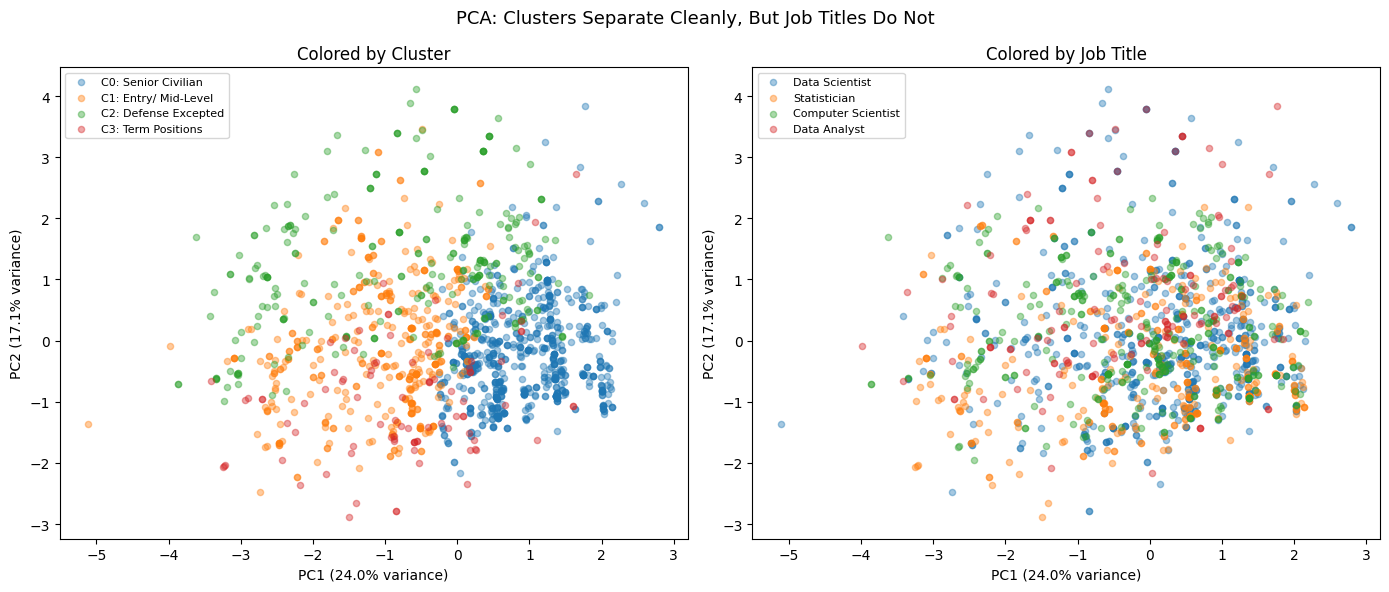

In [ ]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: color by cluster
for c in range(4):
    mask = df_data['Cluster'] == c
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=20,
                label=cluster_labels[c].replace('\n', ' '))
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax1.set_title('Colored by Cluster')
ax1.legend(fontsize=8)

# Right: color by job title
colors = {'Data Scientist': '#1f77b4', 'Statistician': '#ff7f0e',
          'Computer Scientist': '#2ca02c', 'Data Analyst': '#d62728'}
for role, color in colors.items():
    mask = df_data['Role'] == role
    ax2.scatter(X_pca[mask.values, 0], X_pca[mask.values, 1], alpha=0.4,
                s=20, c=color, label=role)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax2.set_title('Colored by Job Title')
ax2.legend(fontsize=8)

plt.suptitle('PCA: Clusters Separate Cleanly, But Job Titles Do Not', fontsize=13)
plt.tight_layout()
plt.show()